<a href="https://colab.research.google.com/github/Priya-DharshiniRamesh/24ADI006_DEEP-LEARNING/blob/main/DL_Word_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploring Word Representations: From Traditional Word Embeddings to Transformers**

**Name:** Priya Dharshini R  
**Roll No.:** 24BAD092  
**Course:** 24ADI306 - Deep Learning  
**Department:** Artificial Intelligence and Data Science  

**Objective**

To study and implement different text representation techniques including
TF-IDF, Word2Vec, FastText, Keras Embedding and BERT, and to visualize
word embeddings and compare their semantic representation, contextual
understanding, OOV handling and computational requirements.

**STEP 1 — Install required libraries**

In [51]:
!pip install -q gensim transformers sentencepiece

**STEP 2 — Import libraries**

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from collections import Counter

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA, TruncatedSVD

from gensim.models import Word2Vec, FastText

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

from transformers import AutoTokenizer, AutoModel

import torch

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.20.0


**STEP 3 — Load Dataset**

In [ ]:
from tensorflow.keras.datasets import imdb

NUM_WORDS = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=NUM_WORDS
)

print("Training reviews:", len(x_train))
print("Testing reviews:", len(x_test))
print("Vocabulary size:", NUM_WORDS)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training reviews: 25000
Testing reviews: 25000
Vocabulary size: 10000


**STEP 4 — Decode IMDB Reviews**

In [ ]:
word_index = imdb.get_word_index()

# IMDB uses special offsets for encoded words
reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(
        reverse_word_index.get(index, "<UNK>")
        for index in encoded_review
    )

texts = [
    decode_review(review)
    for review in x_train[:5000]
]

labels = y_train[:5000]

print("Number of reviews used:", len(texts))
print("\nSample review:\n")
print(texts[0][:1000])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of reviews used: 5000

Sample review:

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are suc

**STEP 5 — Create DataFrame**

In [ ]:
df = pd.DataFrame({
    "review": texts,
    "sentiment": labels
})

df["sentiment"] = df["sentiment"].map({
    0: "Negative",
    1: "Positive"
})

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (5000, 2)


,review,sentiment
0,<START> this film was just brilliant casting l...,Positive
1,<START> big hair big boobs bad music and a gia...,Negative
2,<START> this has to be one of the worst films ...,Negative
3,<START> the <UNK> <UNK> at storytelling the tr...,Positive
4,<START> worst mistake of my life br br i picke...,Negative


**STEP 6 — Dataset Information**

In [ ]:
print("Dataset information:")
print(df.info())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     5000 non-null   object
 1   sentiment  5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB
None

Sentiment distribution:
sentiment
Positive    2546
Negative    2454
Name: count, dtype: int64


**STEP 7 — Text Preprocessing**

In [ ]:
def clean_text(text):
    text = text.lower()

    # Remove IMDB special tokens
    text = text.replace("<start>", " ")
    text = text.replace("<unk>", " ")
    text = text.replace("<unused>", " ")
    text = text.replace("<pad>", " ")

    # Keep only alphabets and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

cleaned_texts = [
    clean_text(text)
    for text in texts
]

print("Original review:")
print(texts[0][:500])

print("\nCleaned review:")
print(cleaned_texts[0][:500])

Original review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re

Cleaned review:
this film was just brilliant casting location scenery story direction everyone s really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and

**STEP 8 — Tokenize Sentences**

In [ ]:
tokenized_sentences = [
    sentence.split()
    for sentence in cleaned_texts
]

print("First tokenized review:")
print(tokenized_sentences[0][:30])

First tokenized review:
['this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyone', 's', 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', 'is', 'an', 'amazing', 'actor']


**STEP 9 — One-Hot Representation**

In [ ]:
sample_words = ["movie", "film", "good", "bad", "story"]

unique_words = sorted(set(sample_words))

one_hot = pd.DataFrame(
    0,
    index=unique_words,
    columns=unique_words
)

for word in unique_words:
    one_hot.loc[word, word] = 1

print("One-Hot Representation:")
display(one_hot)

One-Hot Representation:


,bad,film,good,movie,story
bad,1,0,0,0,0
film,0,1,0,0,0
good,0,0,1,0,0
movie,0,0,0,1,0
story,0,0,0,0,1


**STEP 10 — Bag of Words**

In [ ]:
bow_vectorizer = CountVectorizer(
    max_features=5000
)

bow_matrix = bow_vectorizer.fit_transform(
    cleaned_texts
)

print("Bag of Words matrix shape:", bow_matrix.shape)

print("\nFirst 20 vocabulary words:")
print(
    bow_vectorizer.get_feature_names_out()[:20]
)

Bag of Words matrix shape: (5000, 5000)

First 20 vocabulary words:
['abandoned' 'abc' 'abilities' 'ability' 'able' 'about' 'above' 'abraham'
 'absolute' 'absolutely' 'absurd' 'abuse' 'abusive' 'academy' 'accent'
 'accents' 'accept' 'acceptable' 'acceptance' 'accepted']


**STEP 11 — N-Gram Representation**

In [ ]:
ngram_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    max_features=5000
)

ngram_matrix = ngram_vectorizer.fit_transform(
    cleaned_texts
)

print("N-gram matrix shape:", ngram_matrix.shape)

print("\nSample N-grams:")
print(
    ngram_vectorizer.get_feature_names_out()[:30]
)

N-gram matrix shape: (5000, 5000)

Sample N-grams:
['ability' 'ability to' 'able' 'able to' 'about' 'about and' 'about as'
 'about her' 'about his' 'about how' 'about it' 'about the' 'about this'
 'about to' 'about what' 'above' 'absolute' 'absolutely' 'absolutely no'
 'absurd' 'academy' 'accent' 'accept' 'accident' 'accidentally'
 'according' 'according to' 'accurate' 'across' 'across as']


**STEP 12 — TF-IDF**

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    cleaned_texts
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (5000, 5000)


**STEP 13 — Display TF-IDF Features**

In [ ]:
tfidf_features = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray()[:5],
    columns=tfidf_features
)

print("Number of TF-IDF features:", len(tfidf_features))

display(tfidf_df.iloc[:, :20])

Number of TF-IDF features: 5000


,abandoned,abc,abilities,ability,able,about,above,abraham,absolute,absolutely,absurd,abuse,abusive,academy,accent,accents,accept,acceptable,acceptance,accepted
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.016177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.053217
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


**STEP 14 — TF-IDF Word Similarity using Cosine Similarity**

In [ ]:
query_words = ["movie", "film", "good", "bad", "story"]

# Each word is represented by its TF-IDF values across all reviews
tfidf_word_matrix = tfidf_matrix.T.tocsr()      # shape: (words, reviews)
tfidf_vocab = tfidf_vectorizer.vocabulary_
tfidf_features_all = tfidf_vectorizer.get_feature_names_out()

for word in query_words:

    print("\n" + "=" * 50)
    print("Query Word:", word)

    if word not in tfidf_vocab:
        print("Word not present in the TF-IDF vocabulary.")
        continue

    idx = tfidf_vocab[word]

    scores = cosine_similarity(
        tfidf_word_matrix[idx],
        tfidf_word_matrix
    ).ravel()

    scores[idx] = -1      # ignore the word itself

    top_idx = scores.argsort()[::-1][:5]

    for i in top_idx:
        print(f"{tfidf_features_all[i]:15s} : {scores[i]:.4f}")


Query Word: movie
this            : 0.6783
it              : 0.5840
the             : 0.5728
and             : 0.5415
to              : 0.5397

Query Word: film
the             : 0.6102
of              : 0.5821
to              : 0.5671
is              : 0.5660
this            : 0.5659

Query Word: good
the             : 0.4689
and             : 0.4601
it              : 0.4573
this            : 0.4558
but             : 0.4531

Query Word: bad
this            : 0.3708
it              : 0.3388
movie           : 0.3318
the             : 0.3265
to              : 0.3209

Query Word: story
the             : 0.4591
and             : 0.4339
of              : 0.4205
is              : 0.4202
to              : 0.4099


**STEP 15 — Co-occurrence Matrix**

In [ ]:
# Use a smaller vocabulary for easy visualization
selected_vocab = [
    "movie",
    "film",
    "good",
    "bad",
    "story",
    "actor",
    "acting",
    "great",
    "love",
    "time"
]

cooccurrence = pd.DataFrame(
    0,
    index=selected_vocab,
    columns=selected_vocab
)

window_size = 2

for sentence in tokenized_sentences[:1000]:
    for i, word in enumerate(sentence):
        if word in selected_vocab:

            start = max(0, i - window_size)
            end = min(
                len(sentence),
                i + window_size + 1
            )

            for j in range(start, end):
                if i != j:
                    context_word = sentence[j]

                    if context_word in selected_vocab:
                        cooccurrence.loc[word, context_word] += 1

print("Co-occurrence Matrix:")
display(cooccurrence)

Co-occurrence Matrix:


,movie,film,good,bad,story,actor,acting,great,love,time
movie,8,4,35,30,7,1,1,23,11,8
film,4,6,25,23,5,2,2,28,8,4
good,35,25,6,8,9,3,13,5,1,3
bad,30,23,8,44,2,1,28,0,2,0
story,7,5,9,2,4,0,6,13,12,2
actor,1,2,3,1,0,0,0,8,0,0
acting,1,2,13,28,6,0,2,11,0,1
great,23,28,5,0,13,8,11,4,2,5
love,11,8,1,2,12,0,0,2,0,0
time,8,4,3,0,2,0,1,5,0,10


**STEP 16 — SVD and LSA**

In [ ]:
svd = TruncatedSVD(
    n_components=5,
    random_state=42
)

lsa_matrix = svd.fit_transform(
    tfidf_matrix
)

print("Original TF-IDF shape:", tfidf_matrix.shape)
print("LSA reduced shape:", lsa_matrix.shape)

print("\nExplained variance ratio:")
print(svd.explained_variance_ratio_)

Original TF-IDF shape: (5000, 5000)
LSA reduced shape: (5000, 5)

Explained variance ratio:
[0.0118971  0.01308588 0.01135712 0.00698236 0.00586128]


**STEP 17 — Word2Vec Skip-Gram**

In [ ]:
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,              # Skip-gram
    epochs=10,
    seed=42
)

print("Word2Vec Skip-gram model trained successfully!")
print("Vocabulary size:", len(word2vec_model.wv))

Word2Vec Skip-gram model trained successfully!
Vocabulary size: 9624


**STEP 18 — Check Word2Vec Vector**

In [ ]:
word = "movie"

vector = word2vec_model.wv[word]

print("Word:", word)
print("Vector size:", len(vector))
print("\nFirst 10 vector values:")
print(vector[:10])

Word: movie
Vector size: 100

First 10 vector values:
[ 0.05600149  0.3796739  -0.17316732  0.0645525  -0.41839978  0.17588319
 -0.28534305  0.11347805 -0.6042534   0.27485606]


**STEP 19 — Five Most Similar Words**

In [ ]:
query_words = [
    "movie",
    "film",
    "good",
    "bad",
    "story"
]

for word in query_words:

    print("\n" + "=" * 50)
    print("Query Word:", word)

    similar_words = word2vec_model.wv.most_similar(
        word,
        topn=5
    )

    for similar_word, score in similar_words:
        print(
            f"{similar_word:15s} : {score:.4f}"
        )


Query Word: movie
film            : 0.8847
flick           : 0.7412
dud             : 0.7063
stinker         : 0.6861
rehash          : 0.6799

Query Word: film
movie           : 0.8847
picture         : 0.6514
dud             : 0.6502
travesty        : 0.6481
lowest          : 0.6457

Query Word: good
great           : 0.6999
decent          : 0.6959
bad             : 0.6850
fine            : 0.6610
nice            : 0.6412

Query Word: bad
terrible        : 0.6866
good            : 0.6850
horrible        : 0.6812
awful           : 0.6668
stupid          : 0.6555

Query Word: story
plot            : 0.7577
storyline       : 0.6804
stories         : 0.6382
tale            : 0.6331
fairytale       : 0.6237


**STEP 20 — Word2Vec Cosine Similarity**

In [ ]:
word1 = "movie"
word2 = "film"

similarity = word2vec_model.wv.similarity(
    word1,
    word2
)

print(
    f"Cosine similarity between '{word1}' "
    f"and '{word2}': {similarity:.4f}"
)

Cosine similarity between 'movie' and 'film': 0.8847


**STEP 21 — Word2Vec CBOW and Comparison with Skip-gram**

In [ ]:
cbow_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=0,              # CBOW
    epochs=10,
    seed=42
)

print("Word2Vec CBOW model trained successfully!")
print("Vocabulary size:", len(cbow_model.wv))

cbow_rows = []

for word in query_words:
    skipgram_similar = [x[0] for x in word2vec_model.wv.most_similar(word, topn=5)]
    cbow_similar = [x[0] for x in cbow_model.wv.most_similar(word, topn=5)]

    cbow_rows.append({
        "Word": word,
        "Skip-gram Similar Words": ", ".join(skipgram_similar),
        "CBOW Similar Words": ", ".join(cbow_similar)
    })

display(pd.DataFrame(cbow_rows))

print("\nSimilarity between 'movie' and 'film':")
print("Skip-gram:", round(word2vec_model.wv.similarity("movie", "film"), 4))
print("CBOW     :", round(cbow_model.wv.similarity("movie", "film"), 4))

Word2Vec CBOW model trained successfully!
Vocabulary size: 9624


,Word,Skip-gram Similar Words,CBOW Similar Words
0,movie,"film, flick, dud, stinker, rehash","film, picture, flick, show, sequel"
1,film,"movie, picture, dud, travesty, lowest","movie, picture, documentary, flick, sequel"
2,good,"great, decent, bad, fine, nice","decent, great, bad, nice, cool"
3,bad,"terrible, good, horrible, awful, stupid","good, awful, terrible, stupid, poor"
4,story,"plot, storyline, stories, tale, fairytale","plot, premise, tale, storyline, concept"



Similarity between 'movie' and 'film':
Skip-gram: 0.8847
CBOW     : 0.8917


**STEP 22 — FastText**

In [22]:
fasttext_model = FastText(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

print("FastText model trained successfully!")
print("Vocabulary size:", len(fasttext_model.wv))

FastText model trained successfully!
Vocabulary size: 9624


**STEP 23 — FastText Similar Words**

In [23]:
for word in query_words:

    print("\n" + "=" * 50)
    print("Query Word:", word)

    similar_words = fasttext_model.wv.most_similar(
        word,
        topn=5
    )

    for similar_word, score in similar_words:
        print(
            f"{similar_word:15s} : {score:.4f}"
        )


Query Word: movie
film            : 0.8744
flick           : 0.7041
it              : 0.6601
rehash          : 0.6300
misfire         : 0.6217

Query Word: film
movie           : 0.8744
it              : 0.6360
renaissance     : 0.6352
picture         : 0.6319
misfire         : 0.6252

Query Word: good
goodbye         : 0.7284
decent          : 0.6627
goods           : 0.6463
goo             : 0.6373
nice            : 0.6213

Query Word: bad
lame            : 0.6764
awful           : 0.6584
horrible        : 0.6312
terrible        : 0.6303
good            : 0.6174

Query Word: story
storyline       : 0.7485
stories         : 0.7128
plot            : 0.6958
storytelling    : 0.6489
tale            : 0.6292


**STEP 24 — FastText OOV Experiment**

In [24]:
oov_word = "movieeeee"

print("Test word:", oov_word)

# FastText can create vectors for words using character subwords
fasttext_vector = fasttext_model.wv[oov_word]

print("\nFastText:")
print("Vector generated successfully!")
print("Vector size:", len(fasttext_vector))
print("First 10 values:")
print(fasttext_vector[:10])

print("\nWord2Vec:")

if oov_word in word2vec_model.wv:
    print("Word2Vec generated a vector.")
else:
    print(
        "Word2Vec cannot generate a vector because "
        "the word is not in its vocabulary."
    )

Test word: movieeeee

FastText:
Vector generated successfully!
Vector size: 100
First 10 values:
[-0.10283204  0.05157423  0.04940904 -0.07547543 -0.01220938  0.1726739
  0.05525919 -0.11086402 -0.01395816 -0.09699316]

Word2Vec:
Word2Vec cannot generate a vector because the word is not in its vocabulary.


**STEP 25 — Compare FastText and Word2Vec OOV**

In [25]:
print("OOV Word:", oov_word)

print("\nFastText vocabulary contains word:",
      oov_word in fasttext_model.wv.key_to_index)

print("Word2Vec vocabulary contains word:",
      oov_word in word2vec_model.wv.key_to_index)

print("\nFastText can still generate a vector:",
      fasttext_model.wv[oov_word].shape)

OOV Word: movieeeee

FastText vocabulary contains word: False
Word2Vec vocabulary contains word: False

FastText can still generate a vector: (100,)


**STEP 26 — FastText Nearest Neighbours of Unknown and Rare Words**

In [26]:
unknown_words = ["movieeeee", "terribleee", "amazinggg"]

for w in unknown_words:

    print("\n" + "=" * 50)
    print("Word:", w)
    print("In FastText vocabulary :", w in fasttext_model.wv.key_to_index)
    print("In Word2Vec vocabulary :", w in word2vec_model.wv.key_to_index)

    vec = fasttext_model.wv[w]

    print("FastText nearest neighbours:")
    for sim_word, score in fasttext_model.wv.most_similar(positive=[vec], topn=5):
        print(f"{sim_word:15s} : {score:.4f}")

# Rare word that is inside the vocabulary (least frequent word)
rare_word = fasttext_model.wv.index_to_key[-1]
rare_count = fasttext_model.wv.get_vecattr(rare_word, "count")

print("\n" + "=" * 50)
print(f"Rare word in vocabulary: '{rare_word}' (occurs {rare_count} times)")

print("\nWord2Vec neighbours:")
for sim_word, score in word2vec_model.wv.most_similar(rare_word, topn=5):
    print(f"{sim_word:15s} : {score:.4f}")

print("\nFastText neighbours:")
for sim_word, score in fasttext_model.wv.most_similar(rare_word, topn=5):
    print(f"{sim_word:15s} : {score:.4f}")


Word: movieeeee
In FastText vocabulary : False
In Word2Vec vocabulary : False
FastText nearest neighbours:
movie           : 0.8887
movies          : 0.8020
film            : 0.7672
flick           : 0.7534
films           : 0.6751

Word: terribleee
In FastText vocabulary : False
In Word2Vec vocabulary : False
FastText nearest neighbours:
terrible        : 0.9760
horrible        : 0.8615
terribly        : 0.8007
horribly        : 0.7087
horrid          : 0.6980

Word: amazinggg
In FastText vocabulary : False
In Word2Vec vocabulary : False
FastText nearest neighbours:
amazing         : 0.9648
amazingly       : 0.7706
fantastic       : 0.7002
blazing         : 0.6997
outstanding     : 0.6783

Rare word in vocabulary: 'submarine' (occurs 2 times)

Word2Vec neighbours:
loony           : 0.9011
slack           : 0.8824
improvised      : 0.8811
extremes        : 0.8808
amok            : 0.8766

FastText neighbours:
marine          : 0.8241
borderline      : 0.8008
marines         : 0.7674
r

**STEP 27 — Keras Tokenization**

In [27]:
keras_tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

keras_tokenizer.fit_on_texts(cleaned_texts)

sequences = keras_tokenizer.texts_to_sequences(
    cleaned_texts
)

word_index_keras = keras_tokenizer.word_index

vocab_size = min(
    10000,
    len(word_index_keras) + 1
)

max_length = 200

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Keras vocabulary size:", vocab_size)
print("Maximum sequence length:", max_length)
print("Padded sequence shape:", padded_sequences.shape)

Keras vocabulary size: 9644
Maximum sequence length: 200
Padded sequence shape: (5000, 200)


**STEP 28 — Create Keras Embedding Model**

In [28]:
embedding_model = Sequential([
    tf.keras.Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    GlobalAveragePooling1D(),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

embedding_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

embedding_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       617,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,329 (2.36 MB)

 Trainable params: 619,329 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

**STEP 29 — Prepare Sentiment Labels**

In [29]:
keras_labels = np.array(labels)

print("Number of samples:", len(keras_labels))
print("First 10 labels:", keras_labels[:10])

Number of samples: 5000
First 10 labels: [1 0 0 1 0 0 1 0 1 0]


**STEP 30 — Train Keras Embedding Model**

In [30]:
history = embedding_model.fit(
    padded_sequences,
    keras_labels,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5810 - loss: 0.6883 - val_accuracy: 0.5890 - val_loss: 0.6750
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6967 - loss: 0.6331 - val_accuracy: 0.7580 - val_loss: 0.5889
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8133 - loss: 0.4953 - val_accuracy: 0.8010 - val_loss: 0.4706


**STEP 31 — Generate Keras Embeddings**

In [31]:
# Get the actual trained embedding layer
keras_embedding_layer = embedding_model.layers[0]

keras_embedding_weights = (
    keras_embedding_layer.get_weights()[0]
)

print(
    "Keras embedding matrix shape:",
    keras_embedding_weights.shape
)

Keras embedding matrix shape: (9644, 64)


**STEP 32 — Check Keras Word Embedding**

In [32]:
keras_word = "movie"

keras_word_id = keras_tokenizer.word_index.get(
    keras_word
)

if keras_word_id is not None and keras_word_id < vocab_size:

    keras_vector = keras_embedding_weights[
        keras_word_id
    ]

    print("Word:", keras_word)
    print("Word ID:", keras_word_id)
    print("Embedding size:", len(keras_vector))
    print("\nFirst 10 values:")
    print(keras_vector[:10])

else:
    print("Word not available in Keras vocabulary.")

Word: movie
Word ID: 20
Embedding size: 64

First 10 values:
[ 0.00865206  0.07770324  0.0464128   0.13943261 -0.09891041 -0.11168469
 -0.09168997  0.07575221 -0.18499321  0.04579393]


**STEP 33 — Load BERT**

In [33]:
bert_tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

bert_model = AutoModel.from_pretrained(
    "bert-base-uncased"
)

bert_model.eval()

print("BERT loaded successfully!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully!


**STEP 34 — BERT Sentence Embedding**

In [34]:
def get_bert_sentence_embedding(sentence):

    inputs = bert_tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    # Mean pooling of token representations
    embedding = outputs.last_hidden_state.mean(
        dim=1
    )

    return embedding.numpy()[0]

**STEP 35 — Test BERT Sentence Embedding**

In [35]:
sentence = "Machine learning is useful."

embedding = get_bert_sentence_embedding(
    sentence
)

print("Sentence:", sentence)
print("BERT embedding size:", len(embedding))

print("\nFirst 10 values:")
print(embedding[:10])

Sentence: Machine learning is useful.
BERT embedding size: 768

First 10 values:
[ 0.01009452 -0.12855615 -0.28240767  0.14775623  0.19078219 -0.5140916
 -0.08299152  0.51559484  0.00432862 -0.54491305]


**STEP 36 — BERT Contextual Word Embedding**

In [36]:
def get_bert_word_embedding(sentence, target_word):

    words = sentence.split()

    inputs = bert_tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    word_ids = inputs.word_ids(
        batch_index=0
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    hidden_states = outputs.last_hidden_state[0]

    target_positions = [
        i
        for i, word_id in enumerate(word_ids)
        if word_id is not None
        and words[word_id].lower().strip(".,!?") == target_word.lower()
    ]

    if len(target_positions) == 0:
        raise ValueError(
            f"Target word '{target_word}' not found."
        )

    # Average subword tokens belonging to the target word
    target_embedding = hidden_states[
        target_positions
    ].mean(dim=0)

    return target_embedding.numpy()

**STEP 37 — BERT Same Word in Different Contexts**

In [37]:
sentence1 = "I went to the bank to deposit money."

sentence2 = "The fisherman sat on the bank of the river."

bank_embedding1 = get_bert_word_embedding(
    sentence1,
    "bank"
)

bank_embedding2 = get_bert_word_embedding(
    sentence2,
    "bank"
)

print("Sentence 1:")
print(sentence1)

print("\nSentence 2:")
print(sentence2)

print("\nEmbedding size:", len(bank_embedding1))

context_similarity = cosine_similarity(
    [bank_embedding1],
    [bank_embedding2]
)[0][0]

print(
    "\nCosine similarity between the two "
    "'bank' contextual embeddings:",
    round(context_similarity, 4)
)

Sentence 1:
I went to the bank to deposit money.

Sentence 2:
The fisherman sat on the bank of the river.

Embedding size: 768

Cosine similarity between the two 'bank' contextual embeddings: 0.4744


**STEP 38 — Show Difference Between Contextual Embeddings**

In [38]:
difference = np.linalg.norm(
    bank_embedding1 - bank_embedding2
)

print(
    "Euclidean distance between the two "
    "'bank' embeddings:",
    round(difference, 4)
)

if difference > 0:
    print(
        "\nBERT produces different representations "
        "for the word 'bank' in different contexts."
    )

Euclidean distance between the two 'bank' embeddings: 16.3571

BERT produces different representations for the word 'bank' in different contexts.


**STEP 39 — BERT Same-Sense vs Different-Sense Comparison (with Word2Vec)**

In [39]:
finance_1 = "I went to the bank to deposit money."
finance_2 = "She opened a savings account at the bank."
river_1   = "The fisherman sat on the bank of the river."
river_2   = "The river bank was covered with green grass."

emb = {
    "finance_1": get_bert_word_embedding(finance_1, "bank"),
    "finance_2": get_bert_word_embedding(finance_2, "bank"),
    "river_1":   get_bert_word_embedding(river_1, "bank"),
    "river_2":   get_bert_word_embedding(river_2, "bank"),
}

pairs = [
    ("Same sense (finance vs finance)", "finance_1", "finance_2"),
    ("Same sense (river vs river)",     "river_1",   "river_2"),
    ("Different sense (finance vs river)", "finance_1", "river_1"),
    ("Different sense (finance vs river)", "finance_2", "river_2"),
]

bert_rows = []
for label, a, b in pairs:
    sim = cosine_similarity([emb[a]], [emb[b]])[0][0]
    bert_rows.append({"Comparison": label, "BERT cosine similarity": round(float(sim), 4)})

display(pd.DataFrame(bert_rows))

# Static embedding: Word2Vec has ONE vector for "bank" in every sentence
if "bank" in word2vec_model.wv:
    w2v_bank = word2vec_model.wv["bank"]
    print("\nWord2Vec: 'bank' has a single vector (size", len(w2v_bank), ")")
    print("Word2Vec similarity between 'bank' in any two contexts:",
          round(float(cosine_similarity([w2v_bank], [w2v_bank])[0][0]), 4))
else:
    print("\n'bank' is not in the Word2Vec vocabulary.")

,Comparison,BERT cosine similarity
0,Same sense (finance vs finance),0.6589
1,Same sense (river vs river),0.7465
2,Different sense (finance vs river),0.4744
3,Different sense (finance vs river),0.4052



Word2Vec: 'bank' has a single vector (size 100 )
Word2Vec similarity between 'bank' in any two contexts: 1.0


**STEP 40 — PCA Visualization of Word2Vec**

In [40]:
words = list(
    word2vec_model.wv.index_to_key
)

# Limit the number of words for a readable plot
words_for_pca = words[:100]

vectors = np.array([
    word2vec_model.wv[word]
    for word in words_for_pca
])

pca = PCA(
    n_components=2,
    random_state=42
)

reduced_vectors = pca.fit_transform(
    vectors
)

print("Original dimensions:", vectors.shape[1])
print("Reduced dimensions:", reduced_vectors.shape[1])

Original dimensions: 100
Reduced dimensions: 2


**STEP 41 — Plot PCA**

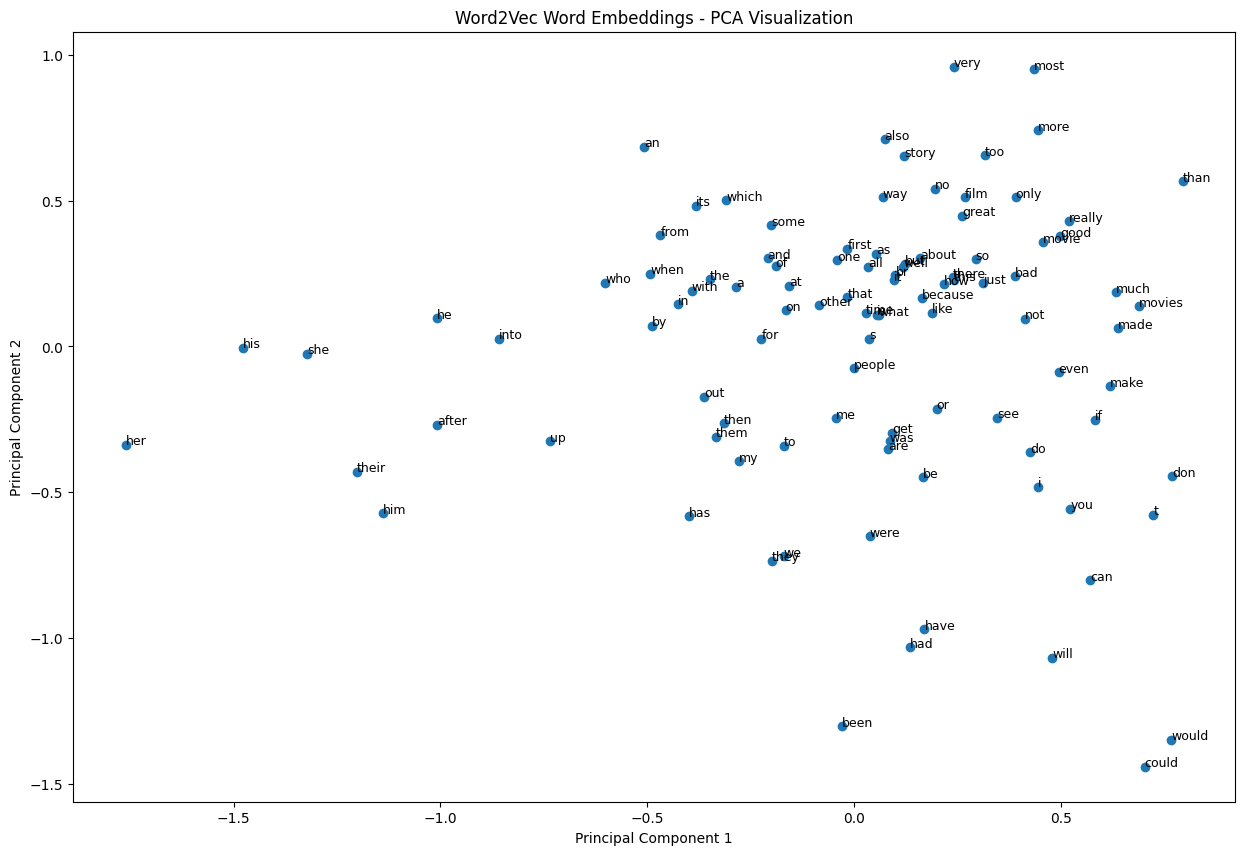

In [41]:
plt.figure(figsize=(15, 10))

plt.scatter(
    reduced_vectors[:, 0],
    reduced_vectors[:, 1]
)

for i, word in enumerate(words_for_pca):

    plt.annotate(
        word,
        (
            reduced_vectors[i, 0],
            reduced_vectors[i, 1]
        ),
        fontsize=9
    )

plt.title(
    "Word2Vec Word Embeddings - PCA Visualization"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

**STEP 42 — Selected Word Visualization**

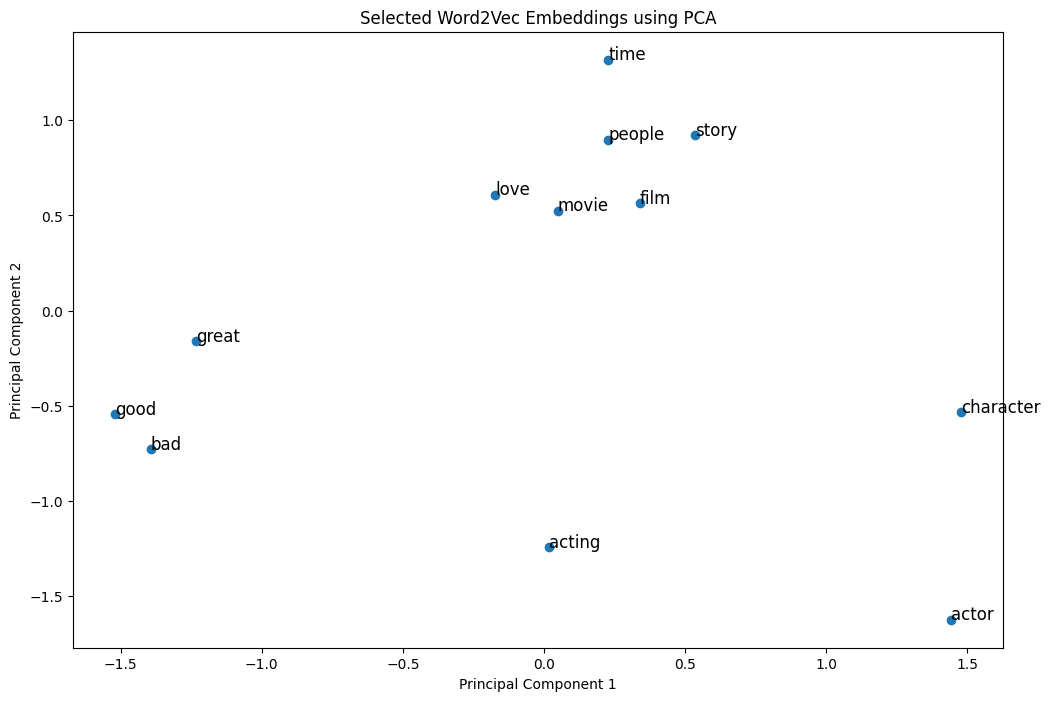

In [42]:
selected_words = [
    "movie",
    "film",
    "good",
    "bad",
    "story",
    "actor",
    "acting",
    "great",
    "love",
    "time",
    "people",
    "character"
]

available_words = [
    word
    for word in selected_words
    if word in word2vec_model.wv
]

selected_vectors = np.array([
    word2vec_model.wv[word]
    for word in available_words
])

pca_selected = PCA(
    n_components=2,
    random_state=42
)

selected_reduced = pca_selected.fit_transform(
    selected_vectors
)

plt.figure(figsize=(12, 8))

plt.scatter(
    selected_reduced[:, 0],
    selected_reduced[:, 1]
)

for i, word in enumerate(available_words):

    plt.annotate(
        word,
        (
            selected_reduced[i, 0],
            selected_reduced[i, 1]
        ),
        fontsize=12
    )

plt.title(
    "Selected Word2Vec Embeddings using PCA"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

**STEP 43 — PCA and t-SNE Visualization of Word Groups**

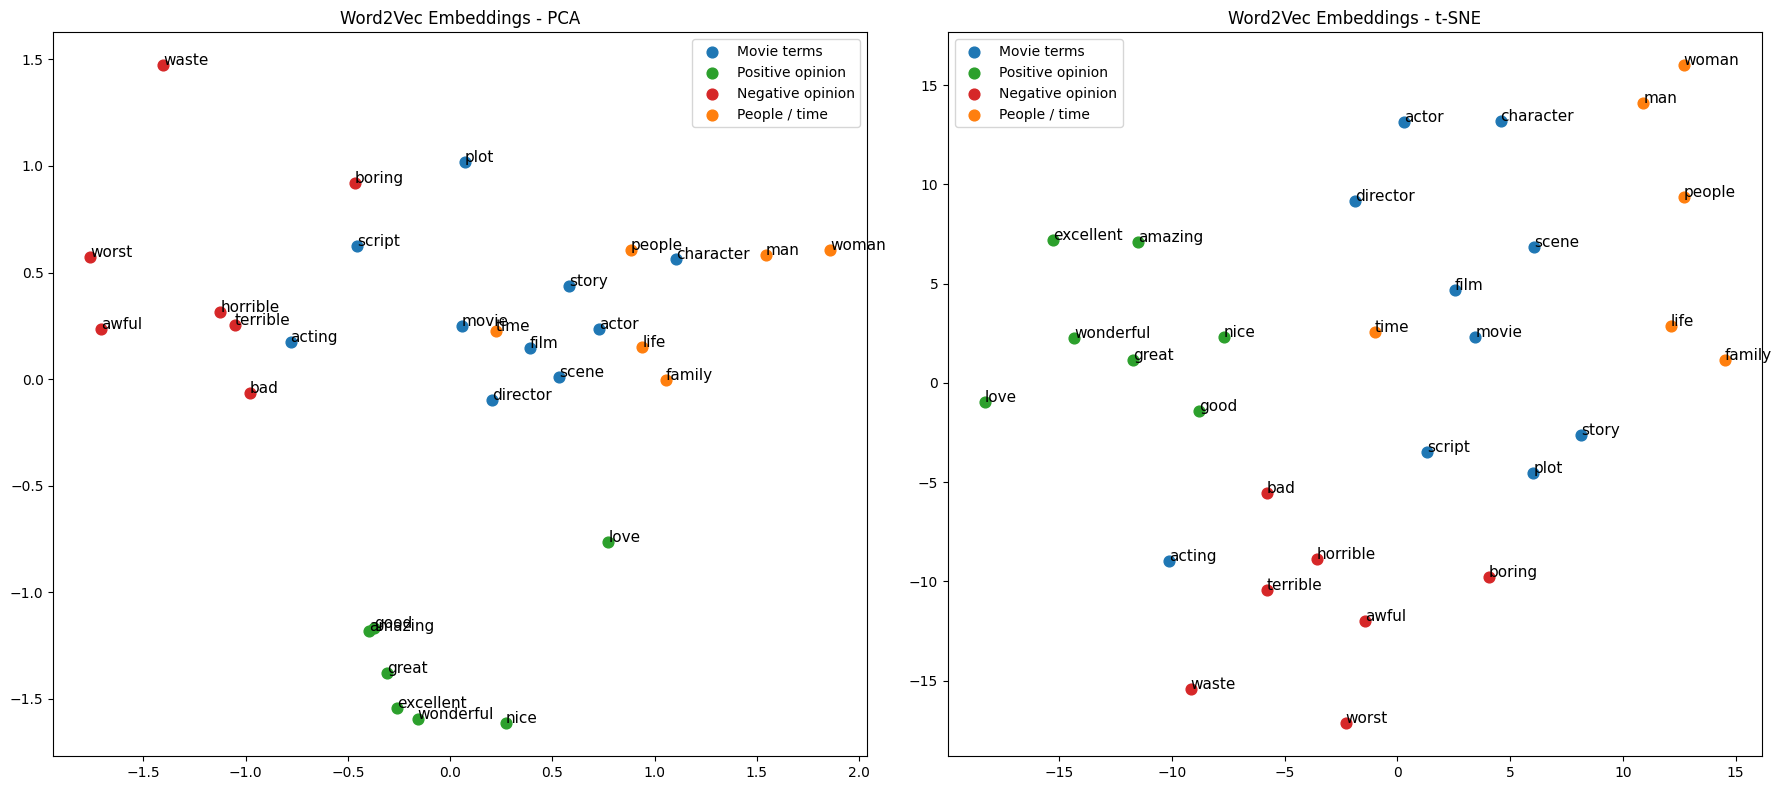

In [43]:
from sklearn.manifold import TSNE

word_groups = {
    "Movie terms": ["movie", "film", "story", "plot", "character", "actor", "acting", "director", "scene", "script"],
    "Positive opinion": ["good", "great", "nice", "wonderful", "excellent", "amazing", "love"],
    "Negative opinion": ["bad", "awful", "terrible", "horrible", "worst", "boring", "waste"],
    "People / time": ["people", "time", "man", "woman", "family", "life"]
}

group_colors = {
    "Movie terms": "tab:blue",
    "Positive opinion": "tab:green",
    "Negative opinion": "tab:red",
    "People / time": "tab:orange"
}

group_words, group_labels = [], []

for group, group_list in word_groups.items():
    for w in group_list:
        if w in word2vec_model.wv:
            group_words.append(w)
            group_labels.append(group)

group_vectors = np.array([word2vec_model.wv[w] for w in group_words])

reducers = {
    "PCA": PCA(n_components=2, random_state=42),
    "t-SNE": TSNE(
        n_components=2,
        perplexity=min(10, len(group_words) - 1),
        init="pca",
        random_state=42
    )
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (name, reducer) in zip(axes, reducers.items()):

    points = reducer.fit_transform(group_vectors)

    for group in word_groups:
        idx = [i for i, g in enumerate(group_labels) if g == group]
        ax.scatter(points[idx, 0], points[idx, 1], label=group, color=group_colors[group], s=60)

    for i, w in enumerate(group_words):
        ax.annotate(w, (points[i, 0], points[i, 1]), fontsize=11)

    ax.set_title(f"Word2Vec Embeddings - {name}")
    ax.legend()

plt.tight_layout()
plt.show()

**STEP 44 — Export Embeddings for TensorFlow Embedding Projector**

After running the next cell, open https://projector.tensorflow.org, click\
**Load**, upload `vecs.tsv` as the vectors file and `meta.tsv` as the metadata\
 file, then switch between PCA, t-SNE and UMAP and take screenshots. Search for\
  words such as *good* or *movie* to see their nearest neighbours.

In [44]:
import io

EXPORT_WORDS = 1000
export_words = word2vec_model.wv.index_to_key[:EXPORT_WORDS]

with io.open("vecs.tsv", "w", encoding="utf-8") as vec_file, \
     io.open("meta.tsv", "w", encoding="utf-8") as meta_file:

    for w in export_words:
        vec_file.write("\t".join(f"{x:.6f}" for x in word2vec_model.wv[w]) + "\n")
        meta_file.write(w + "\n")

print("Exported", len(export_words), "word vectors to vecs.tsv and meta.tsv")

try:
    from google.colab import files
    files.download("vecs.tsv")
    files.download("meta.tsv")
except Exception as e:
    print("Files saved in the working directory (automatic download works only in Colab).")

Exported 1000 word vectors to vecs.tsv and meta.tsv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
from google.colab import files
files.download("meta.tsv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**STEP 45 — Create Word2Vec Results Table**

In [45]:
results = []

for word in query_words:

    similar = word2vec_model.wv.most_similar(
        word,
        topn=5
    )

    results.append({
        "Query Word": word,
        "Top 5 Similar Words": ", ".join(
            [item[0] for item in similar]
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

,Query Word,Top 5 Similar Words
0,movie,"film, flick, dud, stinker, rehash"
1,film,"movie, picture, dud, travesty, lowest"
2,good,"great, decent, bad, fine, nice"
3,bad,"terrible, good, horrible, awful, stupid"
4,story,"plot, storyline, stories, tale, fairytale"


**STEP 46 — Word2Vec vs FastText Comparison**

In [46]:
comparison_words = [
    "movie",
    "film",
    "good",
    "bad",
    "story"
]

comparison_results = []

for word in comparison_words:

    w2v_similar = word2vec_model.wv.most_similar(
        word,
        topn=5
    )

    ft_similar = fasttext_model.wv.most_similar(
        word,
        topn=5
    )

    comparison_results.append({
        "Word": word,
        "Word2Vec Similar Words": ", ".join(
            [x[0] for x in w2v_similar]
        ),
        "FastText Similar Words": ", ".join(
            [x[0] for x in ft_similar]
        )
    })

comparison_results_df = pd.DataFrame(
    comparison_results
)

display(comparison_results_df)

,Word,Word2Vec Similar Words,FastText Similar Words
0,movie,"film, flick, dud, stinker, rehash","film, flick, it, rehash, misfire"
1,film,"movie, picture, dud, travesty, lowest","movie, it, renaissance, picture, misfire"
2,good,"great, decent, bad, fine, nice","goodbye, decent, goods, goo, nice"
3,bad,"terrible, good, horrible, awful, stupid","lame, awful, horrible, terrible, good"
4,story,"plot, storyline, stories, tale, fairytale","storyline, stories, plot, storytelling, tale"


**STEP 47 — Final Comparison Table**

In [47]:
comparison = pd.DataFrame({

    "Technique": [
        "One-Hot Encoding", "Bag of Words", "N-Gram", "TF-IDF", "LSA / SVD",
        "Word2Vec", "FastText", "Keras Embedding", "BERT",
        "GloVe", "ELMo", "SBERT"
    ],

    "Representation": [
        "Sparse binary vector",
        "Sparse frequency vector",
        "Sparse word sequence vector",
        "Weighted sparse vector",
        "Reduced latent vector",
        "Dense vector",
        "Dense subword vector",
        "Learned dense vector",
        "Contextual vector",
        "Dense vector (global co-occurrence)",
        "Contextual vector (BiLSTM)",
        "Sentence-level contextual vector"
    ],

    "Semantic Representation": [
        "Very Low", "Low", "Low to Moderate", "Low to Moderate", "Moderate",
        "High", "High", "Depends on training", "High",
        "High", "High", "High"
    ],

    "Contextual Understanding": [
        "No", "No", "Limited", "No", "Limited",
        "No (static)", "No (static)", "No (static)", "High",
        "No (static)", "Yes", "Yes"
    ],

    "OOV Handling": [
        "No", "Limited", "Limited", "Limited", "No",
        "No native OOV handling", "Subword-based OOV handling",
        "Token-based (OOV token)", "Subword tokenization",
        "No native OOV handling", "Character-based handling",
        "Subword tokenization"
    ],

    "Computational Requirement": [
        "Low", "Low", "Moderate", "Moderate", "Moderate",
        "Moderate", "Moderate to High", "Moderate", "High",
        "Moderate", "High", "High"
    ]
})

display(comparison)

,Technique,Representation,Semantic Representation,Contextual Understanding,OOV Handling,Computational Requirement
0,One-Hot Encoding,Sparse binary vector,Very Low,No,No,Low
1,Bag of Words,Sparse frequency vector,Low,No,Limited,Low
2,N-Gram,Sparse word sequence vector,Low to Moderate,Limited,Limited,Moderate
3,TF-IDF,Weighted sparse vector,Low to Moderate,No,Limited,Moderate
4,LSA / SVD,Reduced latent vector,Moderate,Limited,No,Moderate
5,Word2Vec,Dense vector,High,No (static),No native OOV handling,Moderate
6,FastText,Dense subword vector,High,No (static),Subword-based OOV handling,Moderate to High
7,Keras Embedding,Learned dense vector,Depends on training,No (static),Token-based (OOV token),Moderate
8,BERT,Contextual vector,High,High,Subword tokenization,High
9,GloVe,Dense vector (global co-occurrence),High,No (static),No native OOV handling,Moderate


**STEP 48 — Final Experimental Summary**

In [48]:
print("FINAL EXPERIMENTAL SUMMARY")
print("=" * 60)

print("\n1. Dataset")
print("IMDB movie review dataset")
print("Number of reviews used:", len(texts))

print("\n2. Traditional Representations")
print("One-Hot Encoding")
print("Bag of Words")
print("N-Grams")
print("TF-IDF")
print("Co-occurrence Matrix")
print("SVD / LSA")

print("\n3. Predictive Embeddings")
print("Word2Vec Skip-gram and CBOW")
print("FastText")

print("\n4. Neural Embedding")
print("TensorFlow/Keras Embedding")

print("\n5. Contextual Embedding")
print("BERT")

print("\n6. Visualization")
print("PCA, t-SNE and TensorFlow Embedding Projector (vecs.tsv / meta.tsv)")

print("\n7. Similarity Experiment")
print("Five query words with five similar words each (TF-IDF, Word2Vec, FastText)")

print("\n8. OOV Experiment")
print("FastText vs Word2Vec")

print("\n9. Contextual Experiment")
print("BERT representation of 'bank' in two contexts, with same-sense baseline")

FINAL EXPERIMENTAL SUMMARY

1. Dataset
IMDB movie review dataset
Number of reviews used: 5000

2. Traditional Representations
One-Hot Encoding
Bag of Words
N-Grams
TF-IDF
Co-occurrence Matrix
SVD / LSA

3. Predictive Embeddings
Word2Vec Skip-gram and CBOW
FastText

4. Neural Embedding
TensorFlow/Keras Embedding

5. Contextual Embedding
BERT

6. Visualization
PCA, t-SNE and TensorFlow Embedding Projector (vecs.tsv / meta.tsv)

7. Similarity Experiment
Five query words with five similar words each (TF-IDF, Word2Vec, FastText)

8. OOV Experiment
FastText vs Word2Vec

9. Contextual Experiment
BERT representation of 'bank' in two contexts, with same-sense baseline


**Conclusion**

In this experiment, different methods for representing text and words were
studied and implemented. Traditional techniques such as One-Hot Encoding,
Bag of Words, N-Grams and TF-IDF represent text using word occurrence or
importance. These methods are simple and computationally efficient but they
do not capture deep semantic relationships between words.

Co-occurrence matrices and LSA using SVD were also explored as
frequency-based methods for identifying latent relationships in text.

Word2Vec was implemented using the Skip-gram architecture. It produced
dense word vectors by learning from surrounding words. FastText was also
implemented and its subword-based representation was tested using an
out-of-vocabulary word. The experiment showed why FastText can generate a
representation for words that are not directly present in its vocabulary.

A TensorFlow/Keras Embedding layer was trained to learn dense word
representations from the review dataset. BERT was then used to study
contextual word representations. The word "bank" was tested in two
different sentences, where it represented different meanings. The BERT
embeddings were different for the two contexts, demonstrating contextual
representation.

Both CBOW and Skip-gram were trained and their neighbours compared. Finally, PCA and
t-SNE were used to reduce Word2Vec vectors to two dimensions, and the vectors were
exported to the TensorFlow Embedding Projector. The visualizations showed groups of
movie terms, positive words and negative words.

Overall, traditional methods provide simple numerical representations,
Word2Vec and FastText provide dense semantic representations, and BERT
provides contextual representations by considering the surrounding words.